# Task 1: Table Booking and Online Delivery

## Objective

Investigate whether table booking and online delivery are associated with restaurant ratings and price ranges.

This notebook answers three questions from the Cognifyz Level 2 brief:

1. What percentage of restaurants offer table booking and online delivery?
2. How do average ratings compare for restaurants with and without table booking?
3. How does online delivery availability vary across price ranges?

The original `Dataset.csv` is read only. It is not modified.


## Dataset Overview

The source file is the Cognifyz restaurant dataset at the Level 2 project root.

Relevant columns used in this task:

- `Has Table booking`
- `Has Online delivery`
- `Aggregate rating`
- `Price range`


## Import Libraries


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

BASE_DIR = Path.cwd()
DATA_PATH = (BASE_DIR / "../Dataset.csv").resolve()
FIG_DIR = BASE_DIR / "outputs" / "figures"
TAB_DIR = BASE_DIR / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", BASE_DIR)
print("Dataset path:", DATA_PATH)


Working directory: C:\Users\adity\Documents\Cognifyz\Level-2\Task-1_Table_Booking_Online_Delivery
Dataset path: C:\Users\adity\Documents\Cognifyz\Level-2\Dataset.csv


## Load Dataset


In [2]:
df = pd.read_csv(DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:")
print(list(df.columns))
df.head()


Rows: 9551
Columns: 21
Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Data Validation

Confirm dtypes, missing values, duplicates, and the actual values of the service columns before analysis.


In [3]:
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isna().sum())
print()
print("Duplicate rows:", int(df.duplicated().sum()))
print()
print("Has Table booking values:")
print(df["Has Table booking"].value_counts(dropna=False))
print()
print("Has Online delivery values:")
print(df["Has Online delivery"].value_counts(dropna=False))
print()
print("Price range values:")
print(df["Price range"].value_counts(dropna=False).sort_index())
print()
print("Aggregate rating range:", df["Aggregate rating"].min(), "to", df["Aggregate rating"].max())


Data types:
Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object

Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0

## Analysis: Table Booking Distribution

Percentage formula:

`(count in category / total restaurants) * 100`


In [4]:
total_restaurants = len(df)

table_booking_counts = (
    df["Has Table booking"]
    .value_counts()
    .reindex(["Yes", "No"])
)

table_booking_summary = pd.DataFrame({
    "Table Booking": table_booking_counts.index,
    "Restaurant Count": table_booking_counts.values,
})
table_booking_summary["Percentage"] = (
    table_booking_summary["Restaurant Count"] / total_restaurants * 100
).round(2)

table_booking_summary.to_csv(TAB_DIR / "table_booking_distribution.csv", index=False)
table_booking_summary


,Table Booking,Restaurant Count,Percentage
0,Yes,1158,12.12
1,No,8393,87.88


## Visualization: Table Booking Distribution


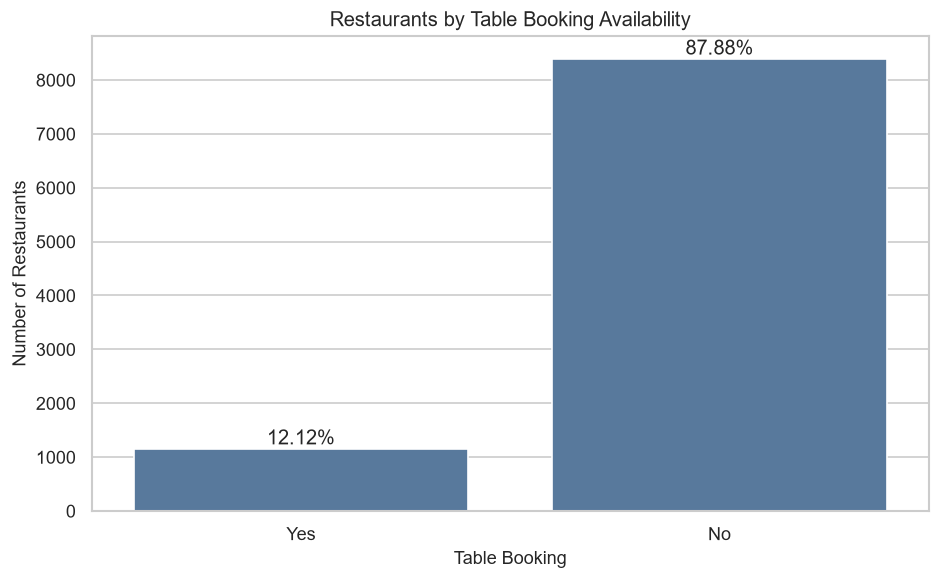

In [5]:
fig, ax = plt.subplots()
sns.barplot(
    data=table_booking_summary,
    x="Table Booking",
    y="Restaurant Count",
    color="#4C78A8",
    ax=ax,
)
ax.set_title("Restaurants by Table Booking Availability")
ax.set_xlabel("Table Booking")
ax.set_ylabel("Number of Restaurants")
for i, row in table_booking_summary.iterrows():
    ax.text(
        i,
        row["Restaurant Count"],
        f'{row["Percentage"]:.2f}%',
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "table_booking_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## Analysis: Online Delivery Distribution


In [6]:
online_delivery_counts = (
    df["Has Online delivery"]
    .value_counts()
    .reindex(["Yes", "No"])
)

online_delivery_summary = pd.DataFrame({
    "Online Delivery": online_delivery_counts.index,
    "Restaurant Count": online_delivery_counts.values,
})
online_delivery_summary["Percentage"] = (
    online_delivery_summary["Restaurant Count"] / total_restaurants * 100
).round(2)

online_delivery_summary.to_csv(TAB_DIR / "online_delivery_distribution.csv", index=False)
online_delivery_summary


,Online Delivery,Restaurant Count,Percentage
0,Yes,2451,25.66
1,No,7100,74.34


## Visualization: Online Delivery Distribution


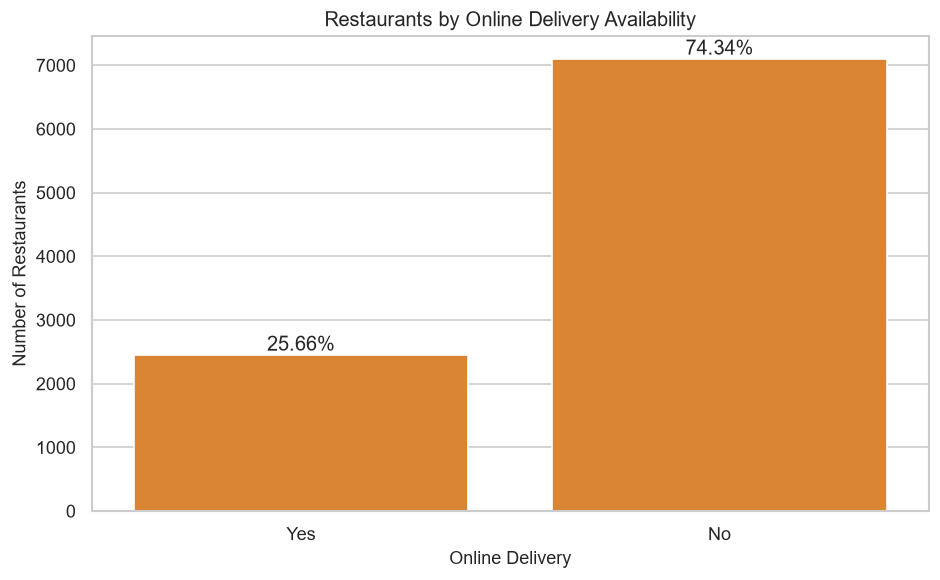

In [7]:
fig, ax = plt.subplots()
sns.barplot(
    data=online_delivery_summary,
    x="Online Delivery",
    y="Restaurant Count",
    color="#F58518",
    ax=ax,
)
ax.set_title("Restaurants by Online Delivery Availability")
ax.set_xlabel("Online Delivery")
ax.set_ylabel("Number of Restaurants")
for i, row in online_delivery_summary.iterrows():
    ax.text(
        i,
        row["Restaurant Count"],
        f'{row["Percentage"]:.2f}%',
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "online_delivery_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## Analysis: Table Booking vs Average Rating

Restaurants are grouped by table-booking availability. The mean of `Aggregate rating` is calculated for each group.


In [8]:
booking_rating = (
    df.groupby("Has Table booking", as_index=False)
    .agg(
        Restaurants=("Aggregate rating", "count"),
        Average_Rating=("Aggregate rating", "mean"),
    )
)
booking_rating = booking_rating.rename(columns={"Has Table booking": "Table Booking"})
booking_rating["Average_Rating"] = booking_rating["Average_Rating"].round(3)
booking_rating = booking_rating.set_index("Table Booking").loc[["Yes", "No"]].reset_index()

booking_rating.to_csv(TAB_DIR / "table_booking_vs_rating.csv", index=False)
booking_rating


,Table Booking,Restaurants,Average_Rating
0,Yes,1158,3.442
1,No,8393,2.559


## Visualization: Table Booking vs Average Rating


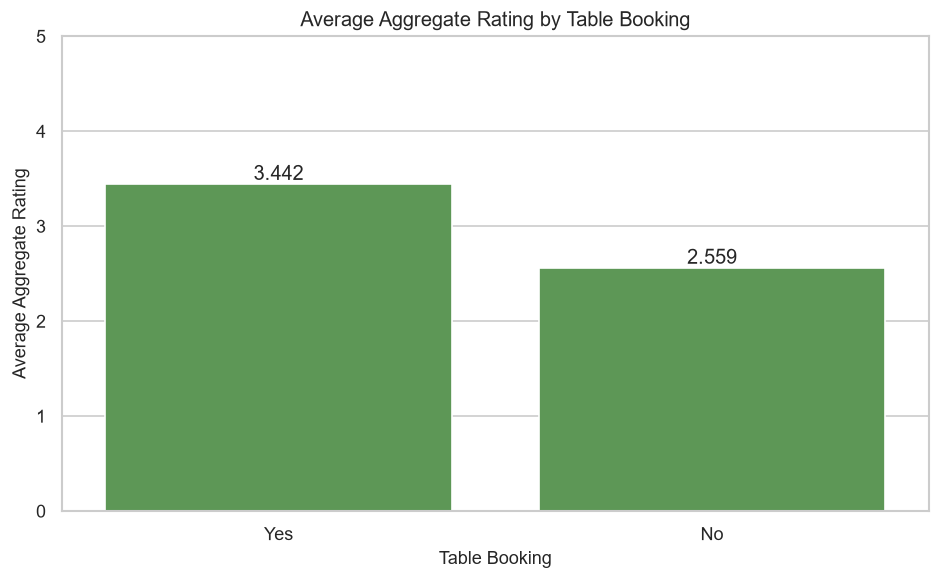

In [9]:
fig, ax = plt.subplots()
sns.barplot(
    data=booking_rating,
    x="Table Booking",
    y="Average_Rating",
    color="#54A24B",
    ax=ax,
)
ax.set_title("Average Aggregate Rating by Table Booking")
ax.set_xlabel("Table Booking")
ax.set_ylabel("Average Aggregate Rating")
ax.set_ylim(0, 5)
for i, row in booking_rating.iterrows():
    ax.text(
        i,
        row["Average_Rating"],
        f'{row["Average_Rating"]:.3f}',
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.savefig(FIG_DIR / "table_booking_vs_rating.png", dpi=300, bbox_inches="tight")
plt.show()


## Analysis: Online Delivery vs Price Range

The dataset is grouped by `Price range` and `Has Online delivery`. Counts and within-price-range delivery percentages are calculated.


In [10]:
delivery_by_price = (
    df.groupby(["Price range", "Has Online delivery"])
    .size()
    .unstack(fill_value=0)
)
delivery_by_price = delivery_by_price.reindex(columns=["Yes", "No"], fill_value=0)
delivery_by_price["Total"] = delivery_by_price["Yes"] + delivery_by_price["No"]
delivery_by_price["Delivery %"] = (
    delivery_by_price["Yes"] / delivery_by_price["Total"] * 100
).round(2)

delivery_price_table = delivery_by_price.reset_index().rename(
    columns={
        "Price range": "Price Range",
        "Yes": "Delivery Yes",
        "No": "Delivery No",
    }
)
delivery_price_table = delivery_price_table[
    ["Price Range", "Delivery Yes", "Delivery No", "Delivery %"]
]
delivery_price_table.to_csv(TAB_DIR / "online_delivery_by_price_range.csv", index=False)
delivery_price_table


Has Online delivery,Price Range,Delivery Yes,Delivery No,Delivery %
0,1,701,3743,15.77
1,2,1286,1827,41.31
2,3,411,997,29.19
3,4,53,533,9.04


## Visualization: Online Delivery vs Price Range


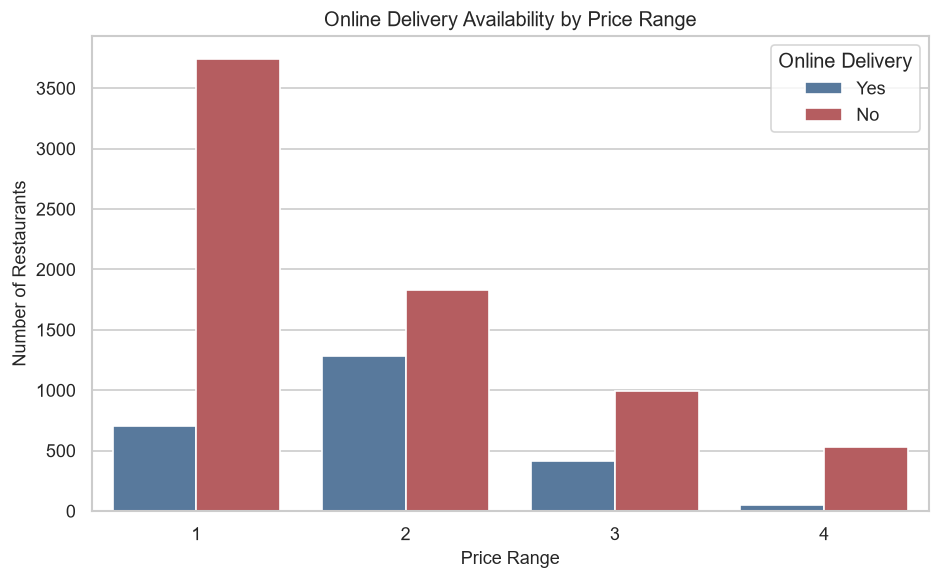

In [11]:
plot_df = delivery_by_price.reset_index().melt(
    id_vars="Price range",
    value_vars=["Yes", "No"],
    var_name="Online Delivery",
    value_name="Restaurant Count",
)

fig, ax = plt.subplots()
sns.barplot(
    data=plot_df,
    x="Price range",
    y="Restaurant Count",
    hue="Online Delivery",
    palette={"Yes": "#4C78A8", "No": "#C44E52"},
    ax=ax,
)
ax.set_title("Online Delivery Availability by Price Range")
ax.set_xlabel("Price Range")
ax.set_ylabel("Number of Restaurants")
ax.legend(title="Online Delivery")
plt.tight_layout()
plt.savefig(FIG_DIR / "online_delivery_by_price_range.png", dpi=300, bbox_inches="tight")
plt.show()


## Results


In [12]:
pct_table_yes = table_booking_summary.loc[
    table_booking_summary["Table Booking"] == "Yes", "Percentage"
].iloc[0]
pct_table_no = table_booking_summary.loc[
    table_booking_summary["Table Booking"] == "No", "Percentage"
].iloc[0]
pct_delivery_yes = online_delivery_summary.loc[
    online_delivery_summary["Online Delivery"] == "Yes", "Percentage"
].iloc[0]
pct_delivery_no = online_delivery_summary.loc[
    online_delivery_summary["Online Delivery"] == "No", "Percentage"
].iloc[0]
avg_yes = booking_rating.loc[booking_rating["Table Booking"] == "Yes", "Average_Rating"].iloc[0]
avg_no = booking_rating.loc[booking_rating["Table Booking"] == "No", "Average_Rating"].iloc[0]
rating_diff = avg_yes - avg_no

print("Total restaurants:", total_restaurants)
print(f"Table booking Yes: {pct_table_yes:.2f}%")
print(f"Table booking No: {pct_table_no:.2f}%")
print(f"Online delivery Yes: {pct_delivery_yes:.2f}%")
print(f"Online delivery No: {pct_delivery_no:.2f}%")
print(f"Average rating with table booking: {avg_yes:.3f}")
print(f"Average rating without table booking: {avg_no:.3f}")
print(f"Rating difference (Yes - No): {rating_diff:.3f}")
print()
print("Online delivery percentage by price range:")
print(delivery_price_table.to_string(index=False))


Total restaurants: 9551
Table booking Yes: 12.12%
Table booking No: 87.88%
Online delivery Yes: 25.66%
Online delivery No: 74.34%
Average rating with table booking: 3.442
Average rating without table booking: 2.559
Rating difference (Yes - No): 0.883

Online delivery percentage by price range:
 Price Range  Delivery Yes  Delivery No  Delivery %
           1           701         3743       15.77
           2          1286         1827       41.31
           3           411          997       29.19
           4            53          533        9.04


## Findings


In [13]:
highest_delivery_row = delivery_price_table.loc[delivery_price_table["Delivery %"].idxmax()]
lowest_delivery_row = delivery_price_table.loc[delivery_price_table["Delivery %"].idxmin()]

findings = f"""
1. {pct_table_yes:.2f}% of restaurants offer table booking. {pct_table_no:.2f}% do not.
2. {pct_delivery_yes:.2f}% of restaurants offer online delivery. {pct_delivery_no:.2f}% do not.
3. Restaurants with table booking have an average rating of {avg_yes:.3f}, compared with {avg_no:.3f} for restaurants without it. The difference is {rating_diff:.3f} points.
4. Online delivery availability varies across price ranges. Price range {int(highest_delivery_row["Price Range"])} has the highest delivery share at {highest_delivery_row["Delivery %"]:.2f}%. Price range {int(lowest_delivery_row["Price Range"])} has the lowest delivery share at {lowest_delivery_row["Delivery %"]:.2f}%.
"""
print(findings.strip())


1. 12.12% of restaurants offer table booking. 87.88% do not.
2. 25.66% of restaurants offer online delivery. 74.34% do not.
3. Restaurants with table booking have an average rating of 3.442, compared with 2.559 for restaurants without it. The difference is 0.883 points.
4. Online delivery availability varies across price ranges. Price range 2 has the highest delivery share at 41.31%. Price range 4 has the lowest delivery share at 9.04%.


## Conclusion

Table booking is offered by a minority of restaurants in this dataset. Online delivery is more common than table booking, but still not majority. Restaurants that offer table booking have a higher average aggregate rating than those that do not. Online delivery is not evenly distributed across price ranges; mid-range restaurants show a higher delivery share than the lowest and highest price ranges.

Saved outputs:

- `outputs/tables/`
- `outputs/figures/`
